# Descision Tree Classifier

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass","sex","fare","embarked","age"] # we are using only these features to work here
target = ["survived"]
titanic.head() # we are not using deck cause it is null for most of the rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# missing data in age and embarked from the features
from sklearn.impute import SimpleImputer

# as age is number , we will go with mean and median it.
imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# as embarked is class , so we are going to use frequency to fill the null data

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# encoding for (sex and embarked)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])



In [8]:
X = titanic[features]
y = titanic[target]

X_train, X_test, y_train,y_test = train_test_split(
    X,y,test_size = 0.2 ,random_state = 42
)

In [9]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


# 0.1 Decision Tree Classifier - No Pruning

In [10]:
from sklearn.tree import DecisionTreeClassifier # bydefault uses "gini Impurity"

model = DecisionTreeClassifier()
model.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy : ",accuracy_score(y_test, y_pred))

accuracy :  0.776536312849162


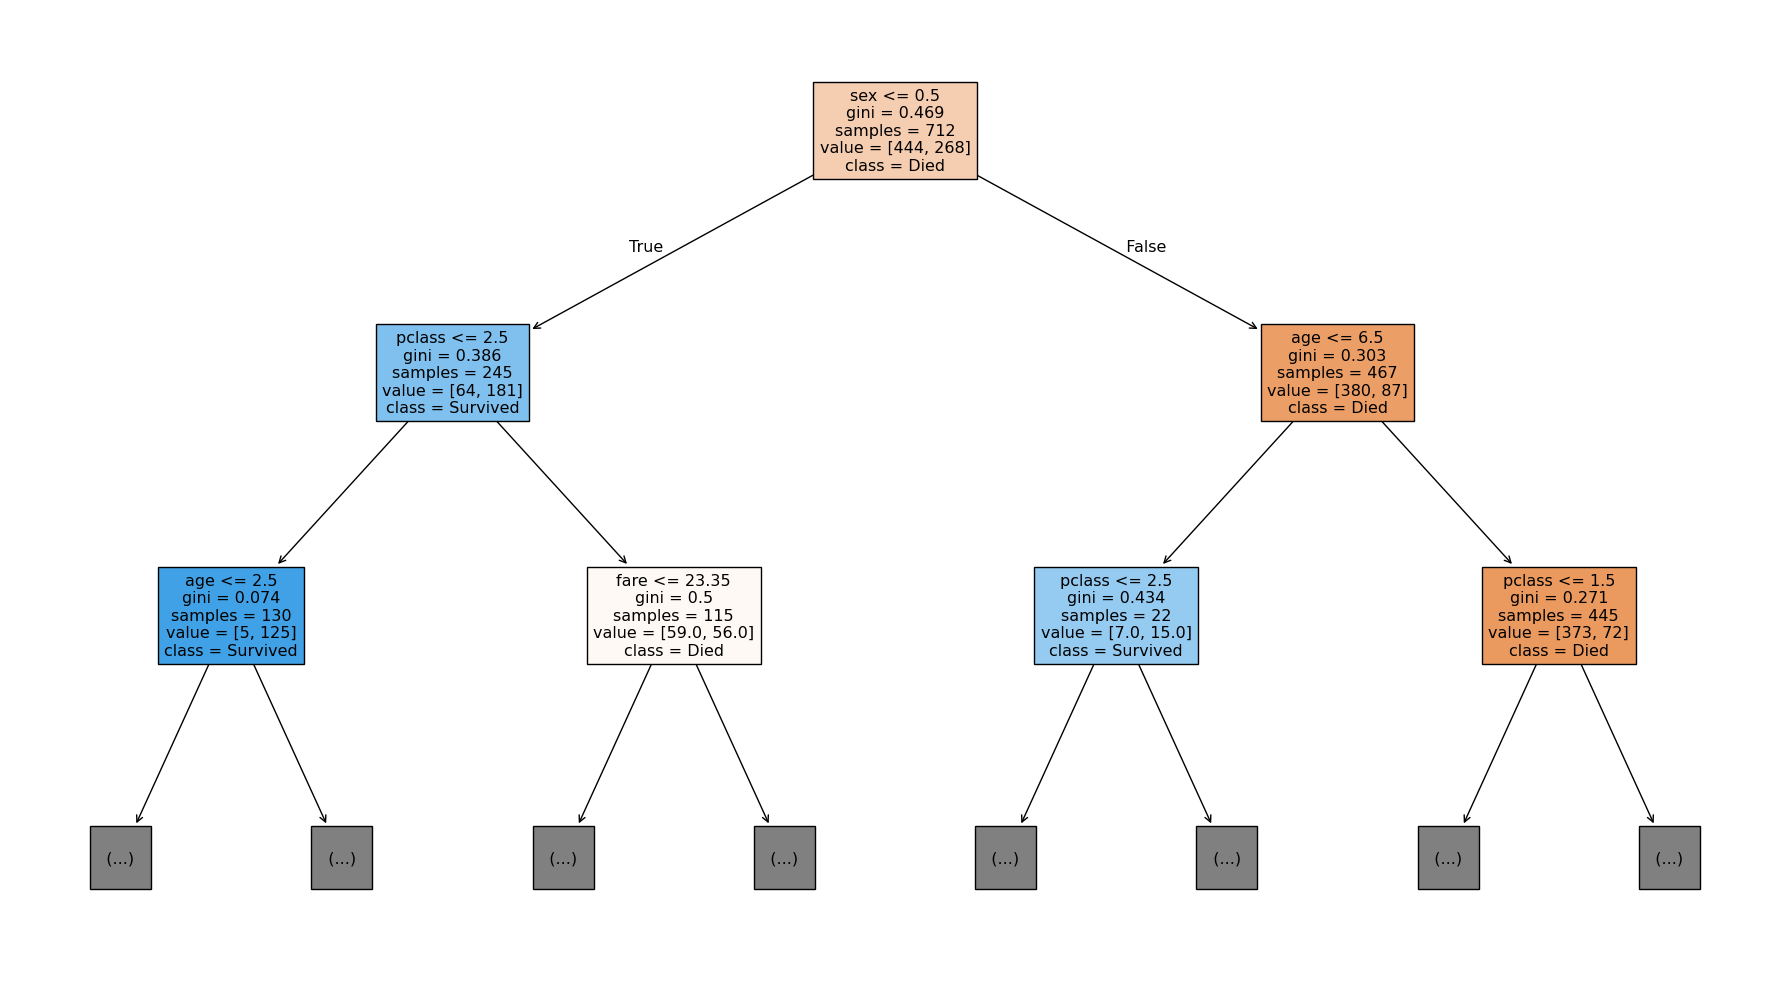

In [12]:
# lets plot the descision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth =2 # remove and see the whole tree
)
plt.tight_layout()
plt.show()

# 0.2 Descision Tree with pre-pruning

for depth :  {2} -> accuracy is :  {0.7653631284916201}
for depth :  {3} -> accuracy is :  {0.7988826815642458}
for depth :  {4} -> accuracy is :  {0.7988826815642458}
for depth :  {5} -> accuracy is :  {0.7988826815642458}
for depth :  {6} -> accuracy is :  {0.8044692737430168}


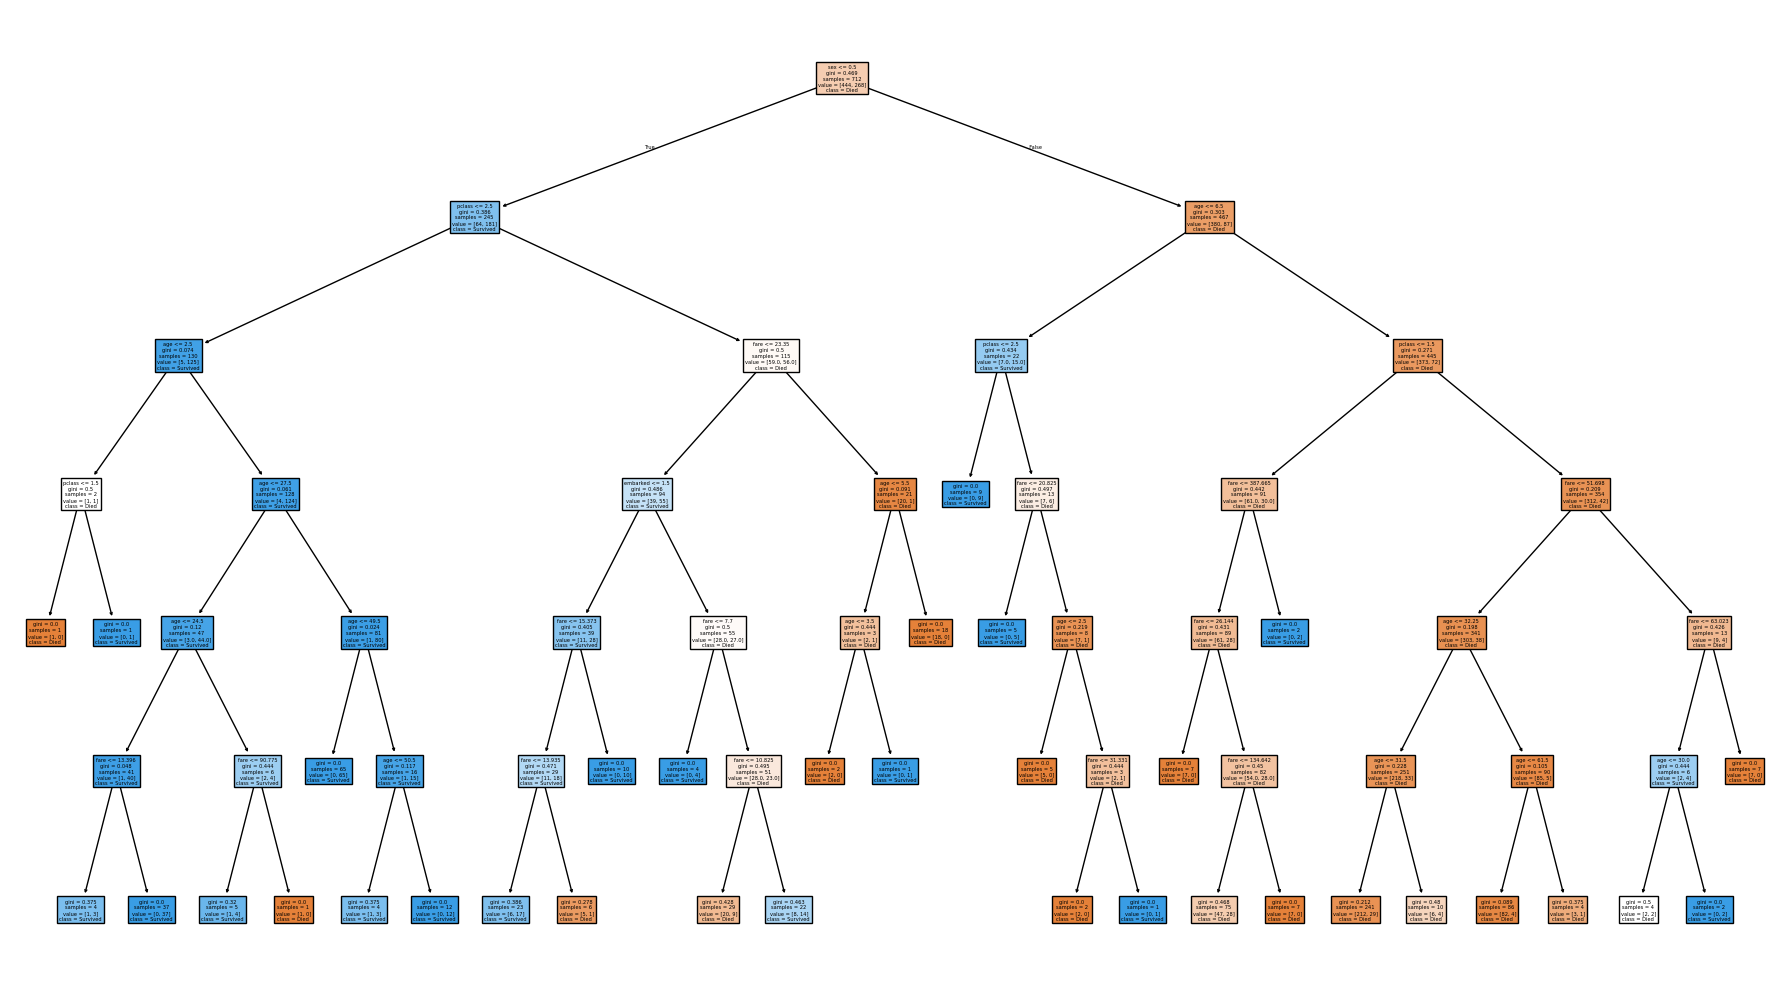

for depth :  {7} -> accuracy is :  {0.7932960893854749}
for depth :  {8} -> accuracy is :  {0.7932960893854749}
for depth :  {9} -> accuracy is :  {0.7877094972067039}
for depth :  {10} -> accuracy is :  {0.7821229050279329}


In [13]:
max_depths = [2,3,4,5,6,7,8,9,10]
# in pre pruning we lime the tree as we limit the height , splits etc.
for depth in max_depths :
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train , y_train)

    acc= model.score(X_test , y_test)
    print("for depth : " ,{depth} , "-> accuracy is : " ,{acc})
    
    if(depth == 6):
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True,
            #max_depth =2 # remove and see the whole tree
        )
        plt.tight_layout()
        plt.show()



for sample_split :  {10} -> accuracy is :  {0.8100558659217877}


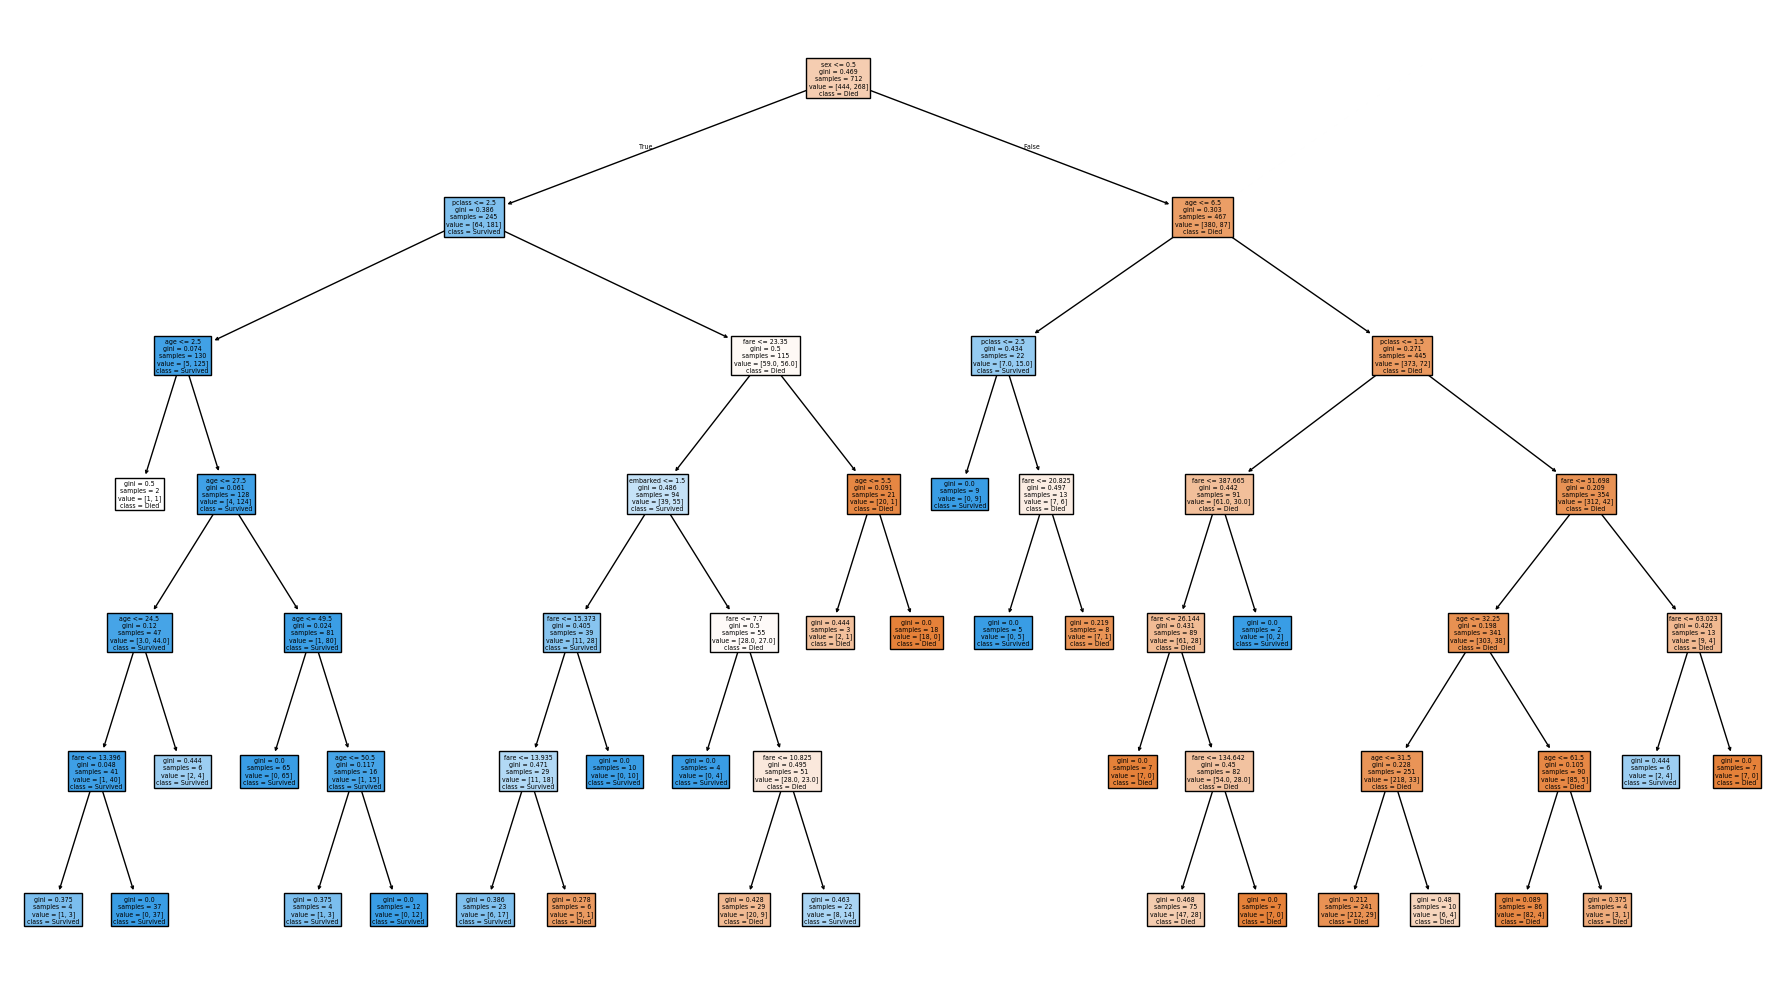

for sample_split :  {15} -> accuracy is :  {0.8044692737430168}
for sample_split :  {20} -> accuracy is :  {0.8044692737430168}
for sample_split :  {25} -> accuracy is :  {0.7988826815642458}
for sample_split :  {30} -> accuracy is :  {0.7877094972067039}


In [14]:
min_samples_splits = [10,15,20,25,30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=6 , min_samples_split =split )
    model.fit(X_train , y_train)

    acc= model.score(X_test , y_test)
    print("for sample_split : " ,{split} , "-> accuracy is : " ,{acc})

    if(split == 10):
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True,
            #max_depth =2 # remove and see the whole tree
        )
        plt.tight_layout()
        plt.show()



 # 0.3 Post Pruning

In [15]:
# for post pruning we have to grow the full tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# ccp alphas , used to remove the unwatned subtree form the tree

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [17]:
# so we train our model for all alphas values
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha= alpha)
    model.fit(X_train, y_train)

    trees.append((model , alpha))

In [18]:
best_acc  =0
best_alpha = 0

for model ,alpha in trees:
    curr_acc = model.score(X_test ,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha


In [19]:
# do from the whole tree we calculated the 
# best_alpha & best_acc
best_acc

# now based on this alpha we will prune the tree


0.8379888268156425

In [20]:
best_model = DecisionTreeClassifier(random_state = 42 , ccp_alpha= best_alpha,max_depth = 6)
best_model.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


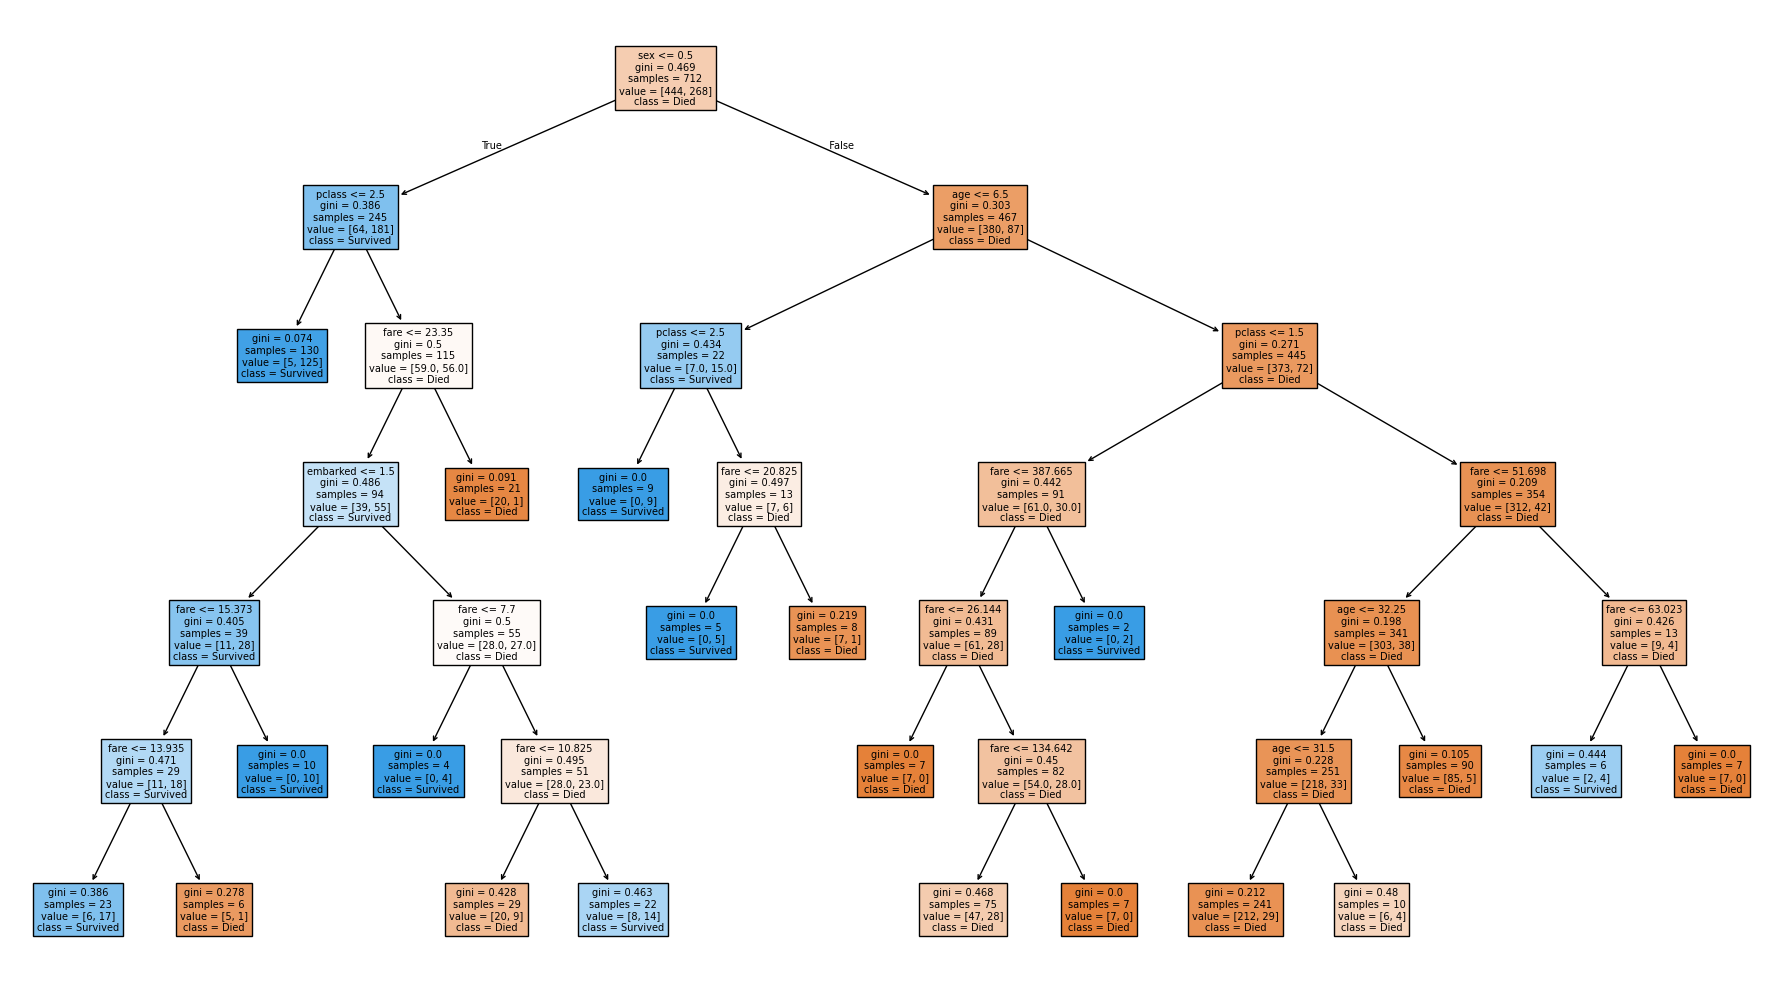

In [21]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    #max_depth =2 # remove and see the whole tree
)
plt.tight_layout()
plt.show()

In [22]:
best_acc # after post pruning and pre pruning 

0.8379888268156425